1. Importation des dépendances (modules)

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

2. Génération des données

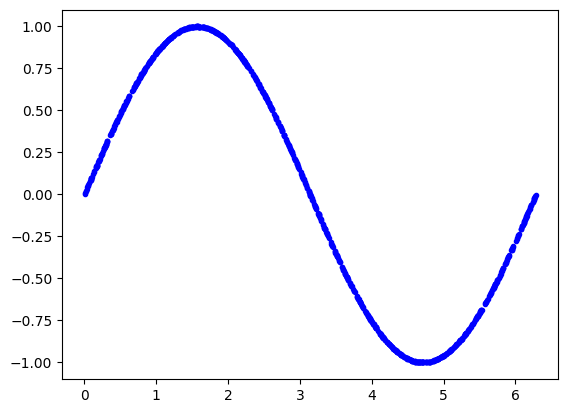

In [2]:
SAMPLES = 1000 # nombres d'échantillons considérés
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

x_values = np.random.uniform(low=0, high=2 * np.pi, size=SAMPLES)
np.random.shuffle(x_values)

y_values = np.sin(x_values)

plt.plot(x_values, y_values, "b.")
plt.show()

3. Ajout des bruits aux données

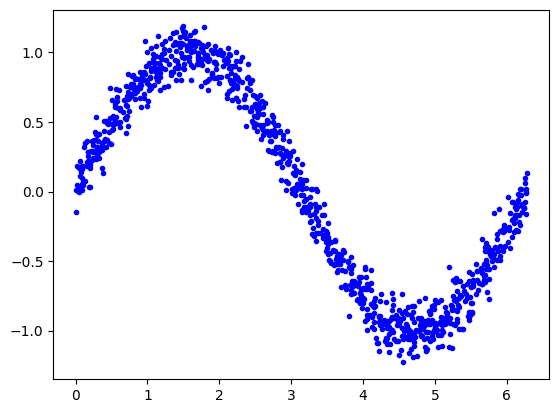

In [3]:
y_values += 0.1 * np.random.randn(*y_values.shape)

plt.plot(x_values, y_values, "b.")
plt.show()

4. Partition des données en trois groupe (Entrainement, Validation et Test)

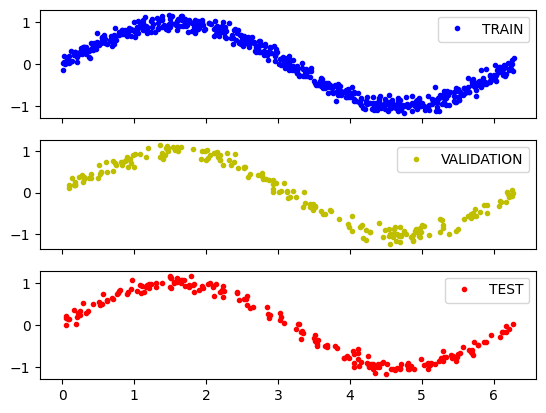

In [4]:
TRAIN_SPLIT = int(0.6 * SAMPLES)                # 60% des données
TEST_SPLIT = int(0.2 * SAMPLES + TRAIN_SPLIT)   # 20% des données

x_train, x_validate, x_test = np.split(x_values, (TRAIN_SPLIT, TEST_SPLIT))
y_train, y_validate, y_test = np.split(y_values, (TRAIN_SPLIT, TEST_SPLIT))

# vérification
assert (x_train.size + x_validate.size + x_test.size) == SAMPLES

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True)

ax1.plot(x_train, y_train, "b.", label="TRAIN")
ax1.legend()
ax2.plot(x_validate, y_validate, "y.", label="VALIDATION")
ax2.legend()
ax3.plot(x_test, y_test, "r.", label="TEST")
ax3.legend()
plt.show()

5. Modèle "deep learning" simple

In [5]:
layer = tf.keras.layers
model_1 = tf.keras.Sequential()

model_1.add(layer.Dense(16, activation="relu", input_shape=(1,))) # première couche
# relu = rectified linear unit, the activation function
model_1.add(layer.Dense(1))
model_1.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

model_1.summary()

C:\Users\itel\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49 (196.00 B)

 Trainable params: 49 (196.00 B)

 Non-trainable params: 0 (0.00 B)

6. Première phase : Entrainement du modèle

In [6]:
history_1 = model_1.fit(x_train, y_train, epochs=1000, batch_size=16,
                        validation_data=(x_validate, y_validate))

Epoch 1/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.4170 - mae: 0.5654 - val_loss: 0.4013 - val_mae: 0.5502
Epoch 2/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.3568 - mae: 0.5182 - val_loss: 0.3543 - val_mae: 0.5132
Epoch 3/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3165 - mae: 0.4883 - val_loss: 0.3146 - val_mae: 0.4816
Epoch 4/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.2823 - mae: 0.4618 - val_loss: 0.2810 - val_mae: 0.4545
Epoch 5/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.2538 - mae: 0.4389 - val_loss: 0.2534 - val_mae: 0.4319
Epoch 6/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 0.2308 - mae: 0.4196 - val_loss: 0.2315 - val_mae: 0.4135
Epoch 7/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.2129 - mae: 0.4033 - val_loss: 0.2148 - val_mae: 0.3990
Epoch 8/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1995 - mae: 0.3904 - val_loss: 0.2024 - val_mae: 0.3881
Epoch 9/1000
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/

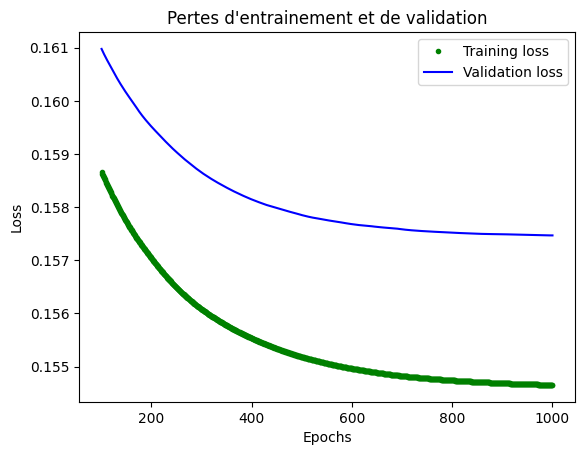

In [7]:
loss = history_1.history["loss"]
val_loss = history_1.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs[100:], loss[100:], "g.", label="Training loss")
plt.plot(epochs[100:], val_loss[100:], "b", label="Validation loss")
plt.title("Pertes d'entrainement et de validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

7. Prediction

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


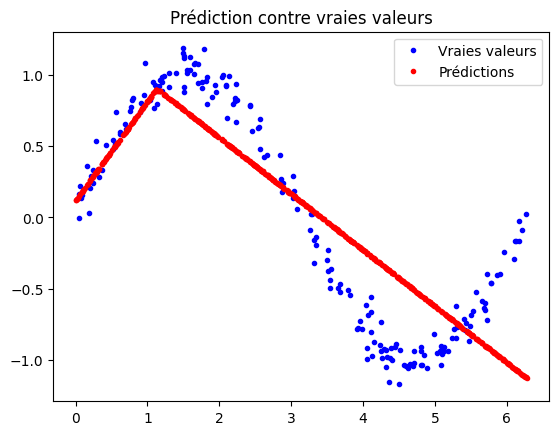

In [8]:
predictions = model_1.predict(x_train)

plt.clf()
plt.title("Prédiction contre vraies valeurs")
plt.plot(x_test, y_test, "b.", label="Vraies valeurs")
plt.plot(x_train, predictions, "r.", label="Prédictions")
plt.legend()
plt.show()

8. Modèle amélioré

In [9]:
model_2 = tf.keras.Sequential()
model_2.add(layer.Dense(16, activation="relu", input_shape=(1,))) # Première couche
model_2.add(layer.Dense(16, activation="relu"))                   # Deuxième couche
model_2.add(layer.Dense(1))                                       # Dernière couche

model_2.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

9. Entrainement de ce deuxième modèle

In [10]:
history_2 = model_2.fit(x_train, y_train, epochs=600, batch_size=16,
                        validation_data=(x_validate, y_validate))

Epoch 1/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.4246 - mae: 0.5707 - val_loss: 0.3918 - val_mae: 0.5443
Epoch 2/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.3427 - mae: 0.5099 - val_loss: 0.3326 - val_mae: 0.5005
Epoch 3/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.2928 - mae: 0.4737 - val_loss: 0.2847 - val_mae: 0.4629
Epoch 4/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.2529 - mae: 0.4413 - val_loss: 0.2471 - val_mae: 0.4318
Epoch 5/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2230 - mae: 0.4142 - val_loss: 0.2192 - val_mae: 0.4060
Epoch 6/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2022 - mae: 0.3934 - val_loss: 0.2004 - val_mae: 0.3878
Epoch 7/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1887 - mae: 0.3781 - val_loss: 0.1883 - val_mae: 0.3746
Epoch 8/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1807 - mae: 0.3674 - val_loss: 0.1811 - val_mae: 0.3665
Epoch 9/600
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

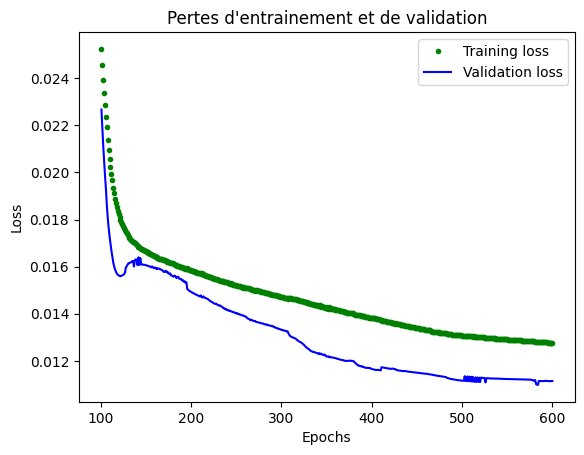

In [11]:
loss = history_2.history["loss"]
val_loss = history_2.history["val_loss"]
epochs = range(1, len(loss) + 1)

plt.plot(epochs[100:], loss[100:], "g.", label="Training loss")
plt.plot(epochs[100:], val_loss[100:], "b", label="Validation loss")
plt.title("Pertes d'entrainement et de validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

10. Test

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0102 - mae: 0.0779
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


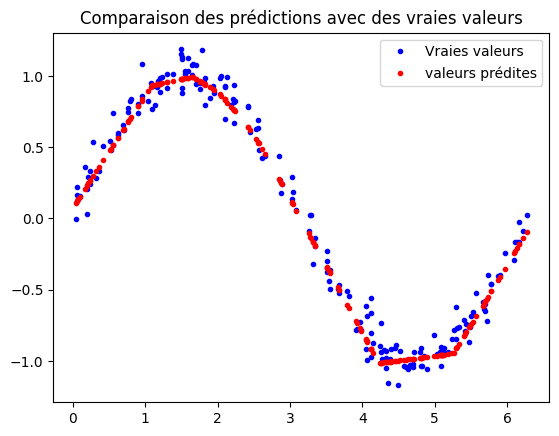

In [12]:
loss = model_2.evaluate(x_test, y_test)
predictions = model_2.predict(x_test)

plt.clf()
plt.title("Comparaison des prédictions avec des vraies valeurs")
plt.plot(x_test, y_test, "b.", label="Vraies valeurs")
plt.plot(x_test, predictions, "r.", label="valeurs prédites")
plt.legend()
plt.show()

11. Conversion vers un modèle compressé

In [13]:
# conversion sans quantification
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
tf_lite_model = converter.convert()

# sauvegarder le modèle
open("sine_model.tflite", "wb").write(tf_lite_model)

# Conversion avec quantification(optimisation)
converter = tf.lite.TFLiteConverter.from_keras_model(model_2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Définition d'une fonction génératrice qui fournit les données test
# comme données représentatives, et dit au convertisseur de l'utiliser
def representative_dataset_generator():
    for value in x_test:
        yield [np.array(value, dtype=np.float32, ndmin=2)]
converter.representative_dataset=representative_dataset_generator
tf_lite_model = converter.convert()
open("sine_model_quantized.tflite", "wb").write(tf_lite_model)

INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmp8fqbo0qh\assets


INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmp8fqbo0qh\assets


Saved artifact at 'C:\Users\itel\AppData\Local\Temp\tmp8fqbo0qh'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2051397448144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397450832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051124357136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397449104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397451024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051450749968: TensorSpec(shape=(), dtype=tf.resource, name=None)
INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpy07aqrld\assets


INFO:tensorflow:Assets written to: C:\Users\itel\AppData\Local\Temp\tmpy07aqrld\assets


Saved artifact at 'C:\Users\itel\AppData\Local\Temp\tmpy07aqrld'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2051397448144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397450832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051124357136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397449104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051397451024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2051450749968: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\itel\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


3736

12. Vérification des modèles

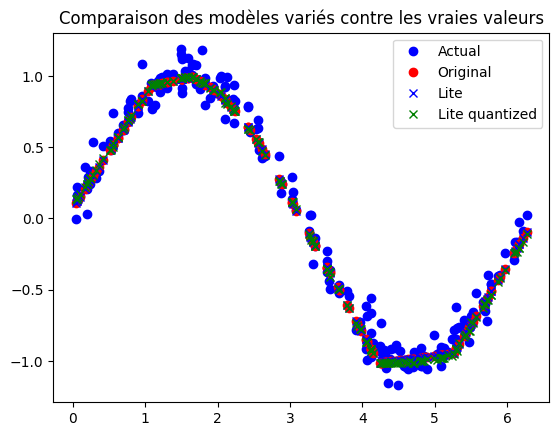

In [15]:
# 1. Instanciation de l'interpréteur
sine_model = tf.lite.Interpreter("sine_model.tflite")
sine_model_quantized = tf.lite.Interpreter("sine_model_quantized.tflite")

# 2. Allocation de la mémoire pour chaque model
sine_model.allocate_tensors()
sine_model_quantized.allocate_tensors()

# 3. Obtenir les indexes des tenseurs d'entrée et de sortie
sine_model_input_index = sine_model.get_input_details()[0]["index"]
sine_model_output_index = sine_model.get_output_details()[0]["index"]
sine_model_quantized_input_index = sine_model_quantized.get_input_details()[0]["index"]
sine_model_quantized_output_index = sine_model_quantized.get_output_details()[0]["index"]

# Créer des vecteurs pour stocker les resultats
sine_model_predictions = []
sine_model_quantized_predictions = []

# Execution de chaque modèle pour chaque valeur et sauvegarde des resultats
for x_value in x_test:
    x_value_tensor = tf.convert_to_tensor([[x_value]], dtype=np.float32)
    sine_model.set_tensor(sine_model_input_index, x_value_tensor)
    # Exécution des inférences
    sine_model.invoke()
    # Lecture des prédictions à partir du tenseur de sortie
    sine_model_predictions.append(sine_model.get_tensor(sine_model_output_index)[0])
    sine_model_quantized.set_tensor(sine_model_quantized_input_index, x_value_tensor)
    sine_model_quantized.invoke()
    sine_model_quantized_predictions.append(sine_model_quantized.get_tensor(sine_model_quantized_output_index)[0])

plt.clf()
plt.title("Comparaison des modèles variés contre les vraies valeurs")
plt.plot(x_test, y_test, "bo", label="Actual")
plt.plot(x_test, predictions, "ro", label="Original")
plt.plot(x_test, sine_model_predictions, "bx", label="Lite")
plt.plot(x_test, sine_model_quantized_predictions, "gx", label="Lite quantized")
plt.legend()
plt.show()

13. Conversion vers C

# Install xxd if it is not available
!apt-get -qq install xxd
# Save the file as a C source file
!xxd -i sine_model_quantized.tflite > sine_model_quantized.cc
# Print the source file
!cat sine_model_quantized.cc